# Hand Gesture Recognition Computer Vision

<img src="https://i.pinimg.com/736x/41/64/4f/41644ff5159e2797f38a6f71caeb190b.jpg">

## 🎯 Project Objective
The goal of this project is to develop a computer vision–based hand gesture recognition system using deep learning.  
The model aims to accurately classify different hand gestures from image data and can be extended to real-time gesture recognition applications.


## 🔍 Exploratory Data Analysis (EDA)
In this section, we explore the dataset structure, class distribution, and sample images to gain insights into the data.  
EDA helps identify potential class imbalance, noise, and variability across subjects and gestures.

### 📁 Dataset Description
The dataset consists of grayscale and RGB hand gesture images collected from multiple subjects.  
Each gesture class is stored in a separate directory, with variations across different users to improve generalization.

In [1]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from PIL import Image

In [2]:
base_path = "/kaggle/input/leapgestrecog/leapGestRecog"

In [3]:
data = []

for subject in sorted(os.listdir(base_path)):
    subject_path = os.path.join(base_path, subject)
    
    if not os.path.isdir(subject_path):
        continue
    
    for gesture in sorted(os.listdir(subject_path)):
        gesture_path = os.path.join(subject_path, gesture)
        
        if not os.path.isdir(gesture_path):
            continue
        
        for img_path in glob.glob(os.path.join(gesture_path, "*.png")):
            data.append({
                "image_path": img_path,
                "label": gesture})

In [4]:
df = pd.DataFrame(data)

## 🧹 Data Preprocessing
Data preprocessing includes resizing images, normalizing pixel values, and encoding gesture labels.  
Optional data augmentation techniques are applied to enhance model robustness and reduce overfitting.

In [5]:
df.head()

,image_path,label
0,/kaggle/input/leapgestrecog/leapGestRecog/00/0...,01_palm
1,/kaggle/input/leapgestrecog/leapGestRecog/00/0...,01_palm
2,/kaggle/input/leapgestrecog/leapGestRecog/00/0...,01_palm
3,/kaggle/input/leapgestrecog/leapGestRecog/00/0...,01_palm
4,/kaggle/input/leapgestrecog/leapGestRecog/00/0...,01_palm


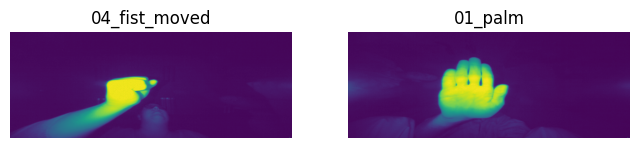

In [7]:
samples = df.sample(2, random_state=42)

plt.figure(figsize=(8,4))
for i, row in enumerate(samples.itertuples(), 1):
    img = Image.open(row.image_path)
    plt.subplot(1,2,i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")
plt.show()

In [8]:
le = LabelEncoder()

In [11]:
df["label_id"] = le.fit_transform(df["label"])

## 🤖 Model Training

In this study, **deep learning–based hand gesture recognition** is performed using  
**Convolutional Neural Networks (CNNs)** combined with **transfer learning** techniques.

Instead of training a network from scratch, **pretrained architectures** are fine-tuned to
leverage knowledge learned from large-scale image datasets.

### 🔧 Models Used
The following state-of-the-art CNN architectures are employed:

- **ResNet** – Deep residual learning for improved gradient flow  
- **MobileNet** – Lightweight and efficient architecture suitable for real-time inference  
- **EfficientNet** – Scalable network optimizing depth, width, and resolution  

### 🎯 Training Objective
The goal of the training process is to:

- Accurately classify **hand gesture images**
- Achieve **high validation accuracy**
- Maintain **efficient training and inference performance**

Transfer learning significantly reduces training time while improving model generalization on
the Leap Gesture Recognition dataset.


In [12]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label_id"], random_state=42)

In [13]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])])

In [14]:
class GestureDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx,"image_path"]).convert("RGB")
        img = transform(img)
        label = self.df.loc[idx,"label_id"]
        return img, label

In [15]:
train_dl = DataLoader(GestureDataset(train_df), batch_size=32, shuffle=True)
val_dl   = DataLoader(GestureDataset(val_df),   batch_size=32, shuffle=False)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
models_dict = {
    "MobileNetV2": models.mobilenet_v2(pretrained=True),
    "ResNet18": models.resnet18(pretrained=True)}

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-d

In [18]:
models_dict["MobileNetV2"].classifier[1] = nn.Linear(
    models_dict["MobileNetV2"].classifier[1].in_features, num_classes)
models_dict["ResNet18"].fc = nn.Linear(
    models_dict["ResNet18"].fc.in_features, num_classes)

for k in models_dict:
    models_dict[k] = models_dict[k].to(device)

In [19]:
criterion = nn.CrossEntropyLoss()

In [20]:
optimizers = {
    "MobileNetV2": torch.optim.Adam(models_dict["MobileNetV2"].parameters(), lr=1e-4),
    "ResNet18": torch.optim.Adam(models_dict["ResNet18"].parameters(), lr=1e-4)}

In [21]:
results = {}

for name, model in models_dict.items():
    optimizer = optimizers[name]

    model.train()
    for images, labels in train_dl:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in val_dl:
            images = images.to(device)
            preds = model(images).argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    results[name] = acc

    print(f"{name} validation accuracy: {acc:.4f}")

MobileNetV2 validation accuracy: 1.0000
ResNet18 validation accuracy: 0.9922


In [22]:
results_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["val_accuracy"]
).sort_values("val_accuracy", ascending=False)

In [23]:
best_model_name = results_df.index[0]
best_model = models_dict[best_model_name]

save_path = f"/kaggle/working/{best_model_name}_best.pt"

torch.save({
    "model_name": best_model_name,
    "model_state": best_model.state_dict(),
    "label_classes": le.classes_.tolist()
}, save_path)